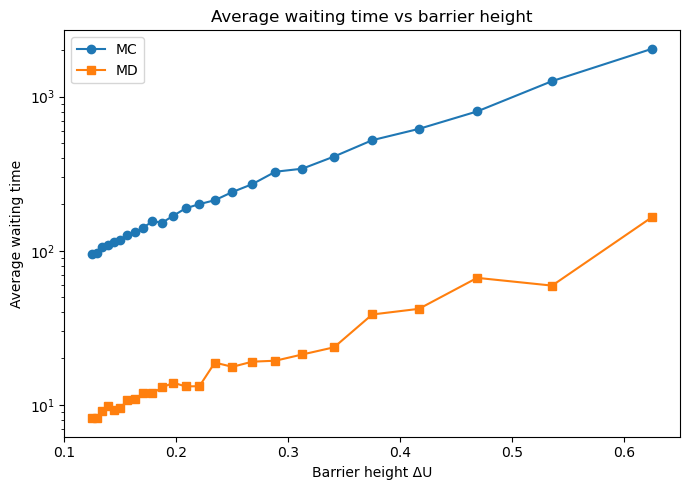

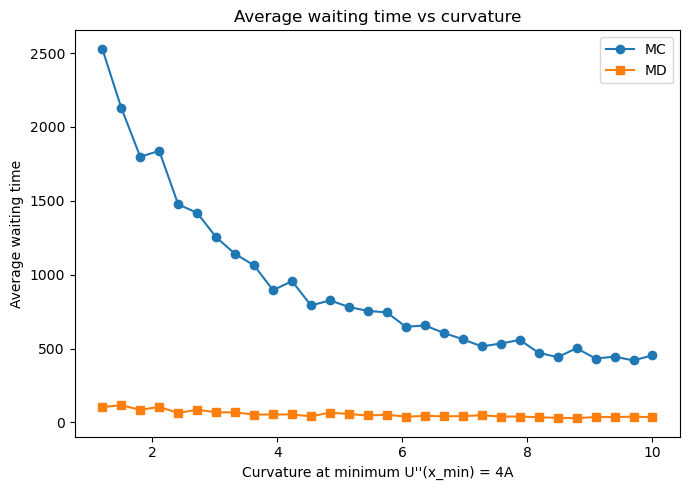

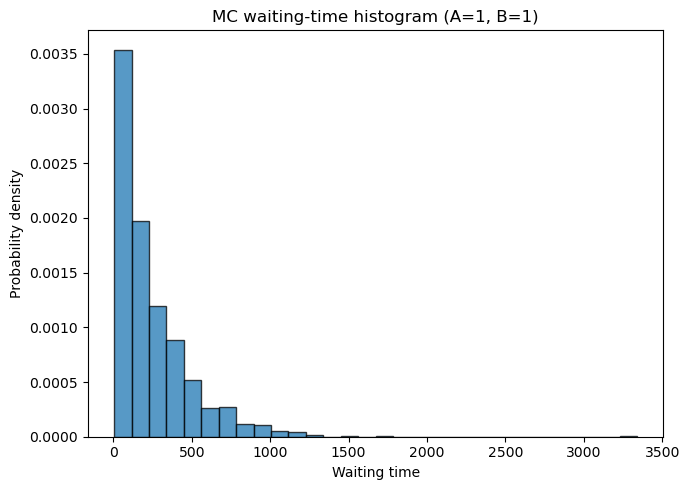

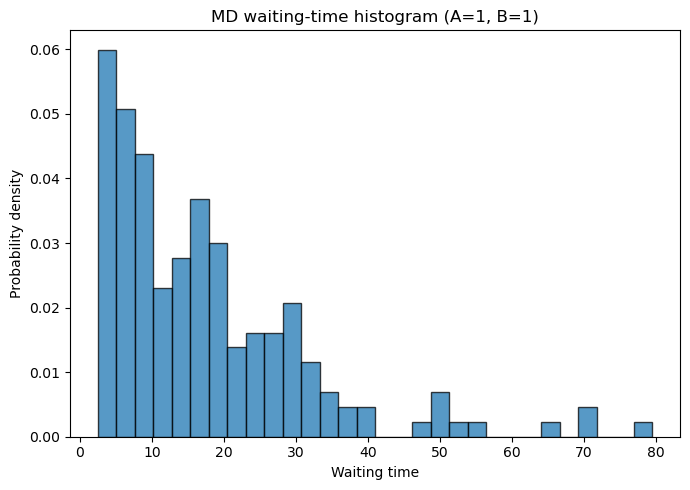

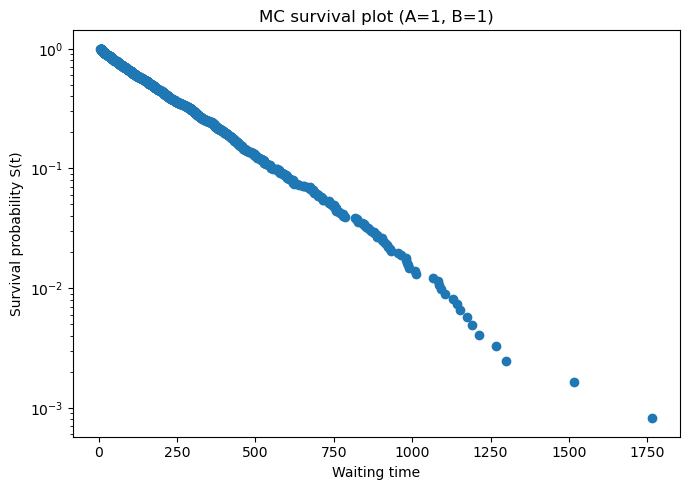

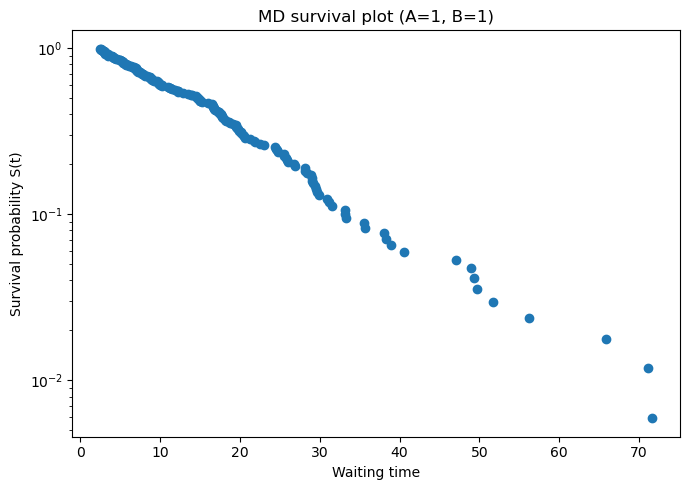

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# ============================================================
# Potential: U(x) = -A x^2 + B x^4
# ============================================================

def U(x, A, B):
    return -A * x**2 + B * x**4

def dUdx(x, A, B):
    return -2 * A * x + 4 * B * x**3

def x_min(A, B):
    return np.sqrt(A / (2 * B))

def barrier_height(A, B):
    return A**2 / (4 * B)

def curvature(A, B):
    return 4 * A

# ============================================================
# Jump detection
# ============================================================

def detect_waiting_times(times, xs, x_c):
    state = 0
    last_transition_time = None
    waiting_times = []

    for t, x in zip(times, xs):
        if x < -x_c:
            new_state = -1
        elif x > x_c:
            new_state = +1
        else:
            new_state = state

        if state == 0 and new_state != 0:
            state = new_state
            last_transition_time = t

        elif new_state != state and new_state != 0:
            if last_transition_time is not None:
                waiting_times.append(t - last_transition_time)
            last_transition_time = t
            state = new_state

    return np.array(waiting_times)

# ============================================================
# Monte Carlo
# ============================================================

@dataclass
class MCParams:
    A: float
    B: float
    beta: float
    dx_max: float = 0.2
    nsteps: int = 200000

def run_mc(params: MCParams):
    A, B, beta = params.A, params.B, params.beta
    x = -x_min(A, B)

    xs = np.zeros(params.nsteps)
    times = np.arange(params.nsteps)

    for step in range(params.nsteps):
        x_trial = x + np.random.uniform(-params.dx_max, params.dx_max)
        dE = U(x_trial, A, B) - U(x, A, B)

        if dE <= 0 or np.random.rand() < np.exp(-beta * dE):
            x = x_trial

        xs[step] = x

    return times, xs

# ============================================================
# Langevin MD
# ============================================================

@dataclass
class MDParams:
    A: float
    B: float
    beta: float
    m: float = 1.0
    gamma: float = 1.0
    dt: float = 0.005
    nsteps: int = 400000
    sample_every: int = 10

def run_md(params: MDParams):
    A, B = params.A, params.B
    beta, m, gamma, dt = params.beta, params.m, params.gamma, params.dt
    kT = 1.0 / beta

    x = -x_min(A, B)
    v = 0.0

    c1 = np.exp(-gamma * dt)
    c2 = np.sqrt((1.0 - c1**2) * kT / m)

    nsave = params.nsteps // params.sample_every
    xs = np.zeros(nsave)
    times = np.zeros(nsave)

    save_idx = 0
    for step in range(params.nsteps):
        F = -dUdx(x, A, B)
        v += 0.5 * dt * F / m

        x += 0.5 * dt * v

        v = c1 * v + c2 * np.random.randn()

        x += 0.5 * dt * v

        F = -dUdx(x, A, B)
        v += 0.5 * dt * F / m

        if step % params.sample_every == 0:
            xs[save_idx] = x
            times[save_idx] = step * dt
            save_idx += 1

    return times, xs

# ============================================================
# Scans
# ============================================================

def scan_barrier_mc(A_fixed, B_values, beta, dx_max=0.2, nsteps=200000):
    barriers, mean_waits = [], []

    for B in B_values:
        params = MCParams(A=A_fixed, B=B, beta=beta, dx_max=dx_max, nsteps=nsteps)
        times, xs = run_mc(params)
        xc = 0.5 * x_min(A_fixed, B)
        waits = detect_waiting_times(times, xs, xc)

        barriers.append(barrier_height(A_fixed, B))
        mean_waits.append(np.mean(waits) if len(waits) > 0 else np.nan)

    return np.array(barriers), np.array(mean_waits)

def scan_barrier_md(A_fixed, B_values, beta, gamma=1.0, dt=0.005,
                    nsteps=400000, sample_every=10):
    barriers, mean_waits = [], []

    for B in B_values:
        params = MDParams(A=A_fixed, B=B, beta=beta, gamma=gamma,
                          dt=dt, nsteps=nsteps, sample_every=sample_every)
        times, xs = run_md(params)
        xc = 0.5 * x_min(A_fixed, B)
        waits = detect_waiting_times(times, xs, xc)

        barriers.append(barrier_height(A_fixed, B))
        mean_waits.append(np.mean(waits) if len(waits) > 0 else np.nan)

    return np.array(barriers), np.array(mean_waits)

def scan_curvature_mc(A_values, DeltaU_fixed, beta, dx_max=0.2, nsteps=200000):
    curvatures, mean_waits = [], []

    for A in A_values:
        B = A**2 / (4 * DeltaU_fixed)
        params = MCParams(A=A, B=B, beta=beta, dx_max=dx_max, nsteps=nsteps)
        times, xs = run_mc(params)
        xc = 0.5 * x_min(A, B)
        waits = detect_waiting_times(times, xs, xc)

        curvatures.append(curvature(A, B))
        mean_waits.append(np.mean(waits) if len(waits) > 0 else np.nan)

    return np.array(curvatures), np.array(mean_waits)

def scan_curvature_md(A_values, DeltaU_fixed, beta, gamma=1.0, dt=0.005,
                      nsteps=400000, sample_every=10):
    curvatures, mean_waits = [], []

    for A in A_values:
        B = A**2 / (4 * DeltaU_fixed)
        params = MDParams(A=A, B=B, beta=beta, gamma=gamma,
                          dt=dt, nsteps=nsteps, sample_every=sample_every)
        times, xs = run_md(params)
        xc = 0.5 * x_min(A, B)
        waits = detect_waiting_times(times, xs, xc)

        curvatures.append(curvature(A, B))
        mean_waits.append(np.mean(waits) if len(waits) > 0 else np.nan)

    return np.array(curvatures), np.array(mean_waits)

# ============================================================
# Plotting
# ============================================================

def make_plot(x_mc, y_mc, x_md, y_md, xlabel, ylabel, title, logy=False):
    plt.figure(figsize=(7, 5))
    if logy:
        plt.semilogy(x_mc, y_mc, 'o-', label='MC')
        plt.semilogy(x_md, y_md, 's-', label='MD')
    else:
        plt.plot(x_mc, y_mc, 'o-', label='MC')
        plt.plot(x_md, y_md, 's-', label='MD')

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_waiting_histogram(waits, title, bins=30):
    if len(waits) == 0:
        print(f"No waiting times for {title}")
        return

    plt.figure(figsize=(7, 5))
    plt.hist(waits, bins=bins, density=True, alpha=0.75, edgecolor='black')
    plt.xlabel("Waiting time")
    plt.ylabel("Probability density")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def survival_function(waits):
    waits = np.sort(waits)
    n = len(waits)
    if n == 0:
        return np.array([]), np.array([])
    S = 1.0 - np.arange(1, n + 1) / n
    return waits, S

def plot_survival(waits, title):
    if len(waits) == 0:
        print(f"No waiting times for {title}")
        return

    t, S = survival_function(waits)
    mask = S > 0

    plt.figure(figsize=(7, 5))
    plt.semilogy(t[mask], S[mask], 'o')
    plt.xlabel("Waiting time")
    plt.ylabel("Survival probability S(t)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ============================================================
# Main
# ============================================================

if __name__ == "__main__":
    np.random.seed(0)
    beta = 5.0

    # --------------------------------------------------------
    # 1) Average waiting time vs barrier height
    # --------------------------------------------------------
    A_fixed = 1.0
    B_values = np.linspace(0.4, 2.0, 25)

    barriers_mc, waits_barrier_mc = scan_barrier_mc(
        A_fixed=A_fixed, B_values=B_values, beta=beta,
        dx_max=0.2, nsteps=200000
    )

    barriers_md, waits_barrier_md = scan_barrier_md(
        A_fixed=A_fixed, B_values=B_values, beta=beta,
        gamma=1.0, dt=0.005, nsteps=400000, sample_every=10
    )

    make_plot(
        barriers_mc, waits_barrier_mc,
        barriers_md, waits_barrier_md,
        xlabel="Barrier height ΔU",
        ylabel="Average waiting time",
        title="Average waiting time vs barrier height",
        logy=True
    )

    # --------------------------------------------------------
    # 2) Average waiting time vs curvature
    # --------------------------------------------------------
    DeltaU_fixed = 0.5
    A_values = np.linspace(0.3, 2.5, 30)

    curv_mc, waits_curv_mc = scan_curvature_mc(
        A_values=A_values, DeltaU_fixed=DeltaU_fixed, beta=beta,
        dx_max=0.2, nsteps=200000
    )

    curv_md, waits_curv_md = scan_curvature_md(
        A_values=A_values, DeltaU_fixed=DeltaU_fixed, beta=beta,
        gamma=1.0, dt=0.005, nsteps=400000, sample_every=10
    )

    make_plot(
        curv_mc, waits_curv_mc,
        curv_md, waits_curv_md,
        xlabel="Curvature at minimum U''(x_min) = 4A",
        ylabel="Average waiting time",
        title="Average waiting time vs curvature",
        logy=False
    )

    # --------------------------------------------------------
    # 3) One representative waiting-time distribution
    #    Use A=1, B=1 as an example
    # --------------------------------------------------------
    A_rep, B_rep = 1.0, 1.0
    x_c_rep = 0.5 * x_min(A_rep, B_rep)

    # MC representative run
    times_mc_rep, xs_mc_rep = run_mc(MCParams(A=A_rep, B=B_rep, beta=beta,
                                              dx_max=0.2, nsteps=300000))
    waits_mc_rep = detect_waiting_times(times_mc_rep, xs_mc_rep, x_c_rep)

    # MD representative run
    times_md_rep, xs_md_rep = run_md(MDParams(A=A_rep, B=B_rep, beta=beta,
                                              gamma=1.0, dt=0.005,
                                              nsteps=600000, sample_every=10))
    waits_md_rep = detect_waiting_times(times_md_rep, xs_md_rep, x_c_rep)

    plot_waiting_histogram(waits_mc_rep, "MC waiting-time histogram (A=1, B=1)")
    plot_waiting_histogram(waits_md_rep, "MD waiting-time histogram (A=1, B=1)")
    plot_survival(waits_mc_rep, "MC survival plot (A=1, B=1)")
    plot_survival(waits_md_rep, "MD survival plot (A=1, B=1)")